---
title: "LSE DS202A 2025: Week 07 - Student Notebook (Python)"
author: "YOUR NAME (YOUR CANDIDATE NUMBER)"
date: 03 March 2026
---

Welcome to week 7 of DS202W! Today we'll explore three powerful dimensionality reduction techniques: PCA, MCA, and Autoencoders using Python.

# 🥅 Learning Objectives

By the end of this lab, you will be able to:

- Understand different approaches to dimensionality reduction
- Apply Principal Component Analysis (PCA) for continuous data
- Use Multiple Correspondence Analysis (MCA) for categorical data  
- Implement neural network autoencoders for non-linear dimensionality reduction
- Compare and interpret results from different dimensionality reduction methods

## ⚙️ Setup (5 mins)

In [3]:
# Load required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Install adjustText if needed: conda -c conda-forge install adjustText
from adjustText import adjust_text
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from prince import MCA  # For Multiple Correspondence Analysis
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

# Set random seeds for reproducibility
np.random.seed(12345)
torch.manual_seed(42)

## 🧑‍🏫 Teaching Moment: The Curse of Dimensionality 🪄

::: callout-tip
As the number of variables (**dimensions**) grows:

* Data become **sparse** — points sit far apart; similarity becomes harder to judge.
* Models risk **overfitting** — they can memorise quirks of high-dimensional noise.
* Computation grows — training becomes slower and sometimes unstable.

**Dimensionality reduction** helps by compressing many variables into **fewer, informative dimensions** that preserve most of the structure:

* **PCA** (continuous data): finds new **linear** axes (principal components) that capture the largest variance.
* **MCA** (categorical data): places categories in space using **chi-square distances** based on co-occurrence patterns.
* **Autoencoders** (neural nets): learn to **squeeze** inputs into a small set of numbers and **rebuild** them, enabling **non-linear** compressions when needed.

Why it matters in practice:

* Fewer, well-chosen dimensions can **reduce overfitting**, **speed up** downstream models, and **clarify** the structure you’re modelling.
* Different methods make **different assumptions** (linearity, data type, distance), which guides which one you should use.

:::

# Part I: Principal Component Analysis (PCA) - Continuous Data (20 mins)

PCA is ideal for continuous numerical data where we want to find linear combinations of variables that capture maximum variance.

## Load and Prepare IQ Data

We'll use IQ test data from the Holzinger-Swineford dataset to demonstrate PCA. The **Holzinger–Swineford IQ dataset** (1939) [^1] measures performance on multiple cognitive tests. We use PCA to summarise broad ability patterns.

[^1]: Holzinger, K. J., & Swineford, F. (1939). A study in factor analysis: The stability of a bi-factor solution. Supplementary Educational Monographs, no. 48. Chicago: University of Chicago, Department of Education. 
The data that you have is a copy of the dataset available through the `holzinger.swineford` library in R. You can have a look at [the documentation of the package](https://www.rdocumentation.org/packages/psychTools/versions/2.5.7.22/topics/holzinger.swineford) for more of a description of the dataset

In [4]:
# Load IQ data
data = pd.read_csv("../data/iq-data.csv")

# Remove non-test columns and prepare data
data_clean = data.drop(columns=['t25_frmbord2', 't26_flags', 'mo', 'ageyr', 'grade', 'female', 'agemo', 'case'], errors='ignore')

# Split data early to avoid bias
X = data_clean.select_dtypes(include=[np.number])  # Keep only numeric columns
y = data.get('school', pd.Series([0] * len(data)))  # Use school as target if available

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12345, stratify=y if len(y.unique()) > 1 else None
)

print(f"Training points: {len(X_train)}")
print(f"Test points: {len(X_test)}")
print(f"Features: {list(X_train.columns)}")

Training points: 240
Test points: 61
Features: ['t01_visperc', 't02_cubes', 't03_frmbord', 't04_lozenges', 't05_geninfo', 't06_paracomp', 't07_sentcomp', 't08_wordclas', 't09_wordmean', 't10_addition', 't11_code', 't12_countdot', 't13_sccaps', 't14_wordrecg', 't15_numbrecg', 't16_figrrecg', 't17_objnumb', 't18_numbfig', 't19_figword', 't20_deduction', 't21_numbpuzz', 't22_probreas', 't23_series', 't24_woody']


## Explore High-Dimensional Relationships

❓ How are the variables in your dataset related?

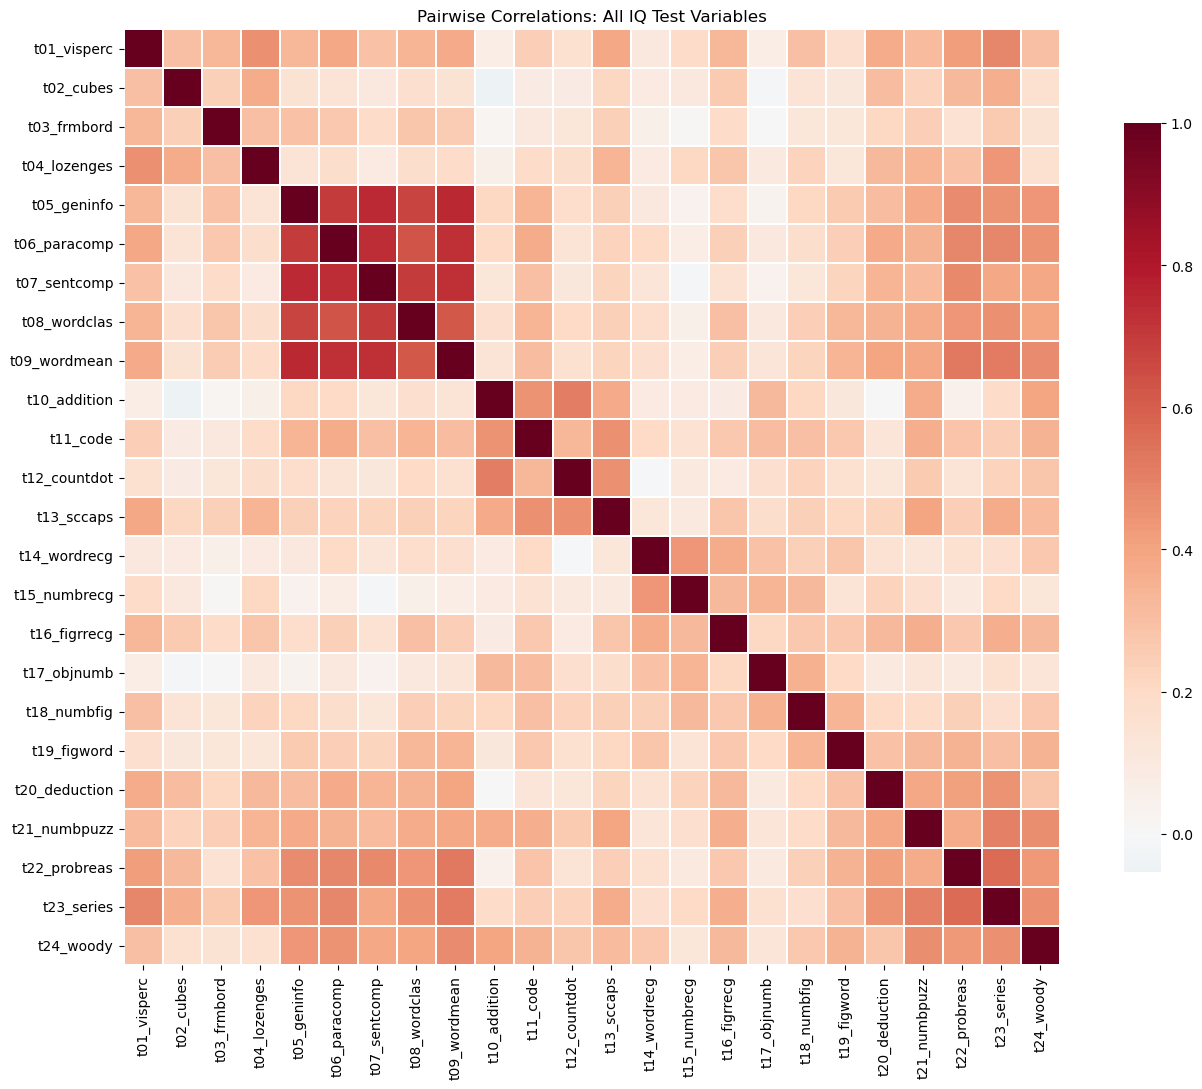

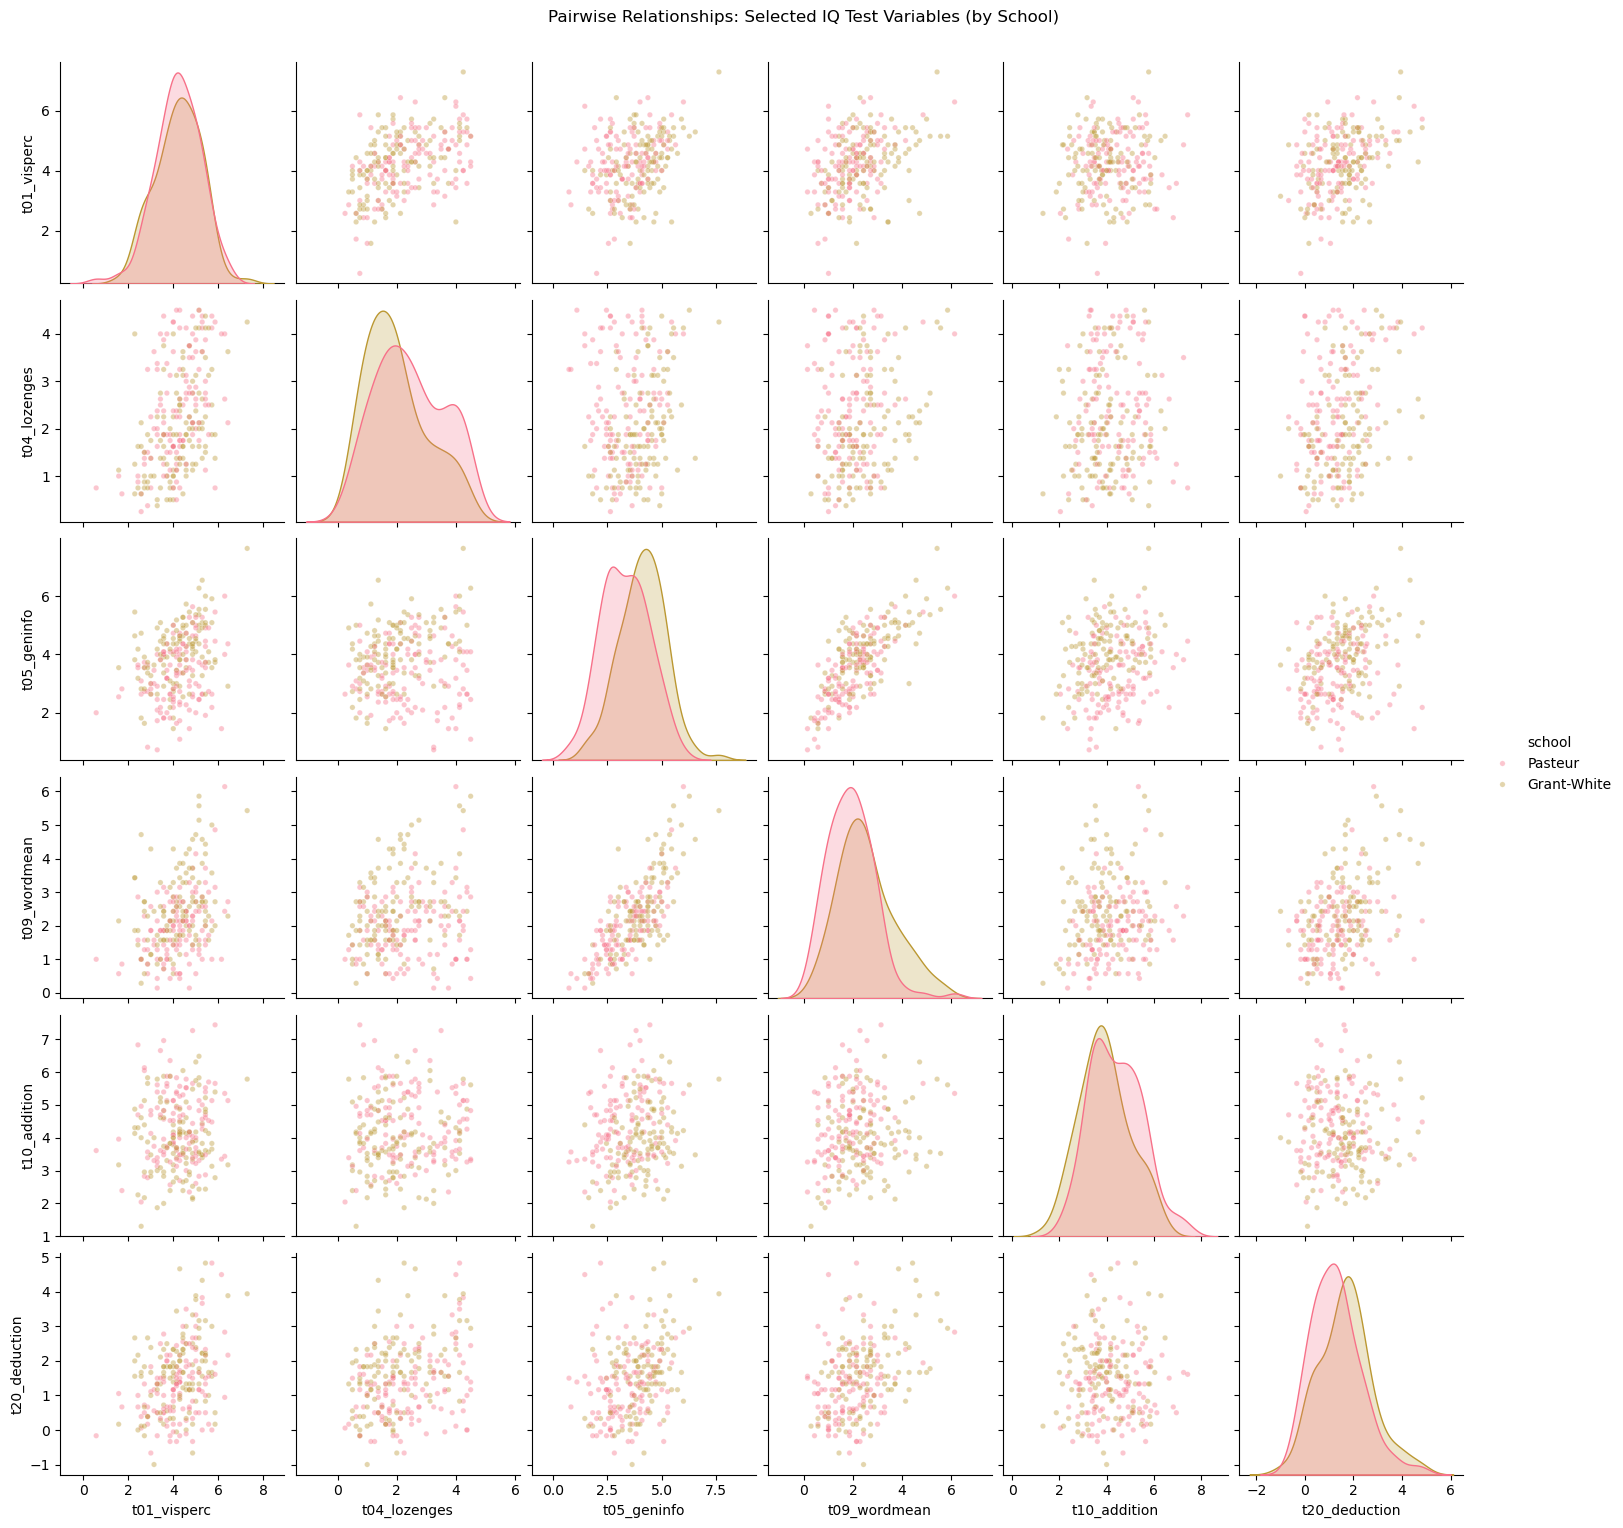

In [10]:
# Plot pairwise graphs

# --- 1. Correlation heatmap for all 24 features ---
plt.figure(figsize=(14, 11))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title('Pairwise Correlations: All IQ Test Variables')
plt.tight_layout()
plt.show()

# --- 2. Pairplot for a representative subset coloured by school ---
subset_cols = ['t01_visperc', 't04_lozenges', 't05_geninfo',
               't09_wordmean', 't10_addition', 't20_deduction']
plot_df = X_train[subset_cols].copy()
plot_df['school'] = y_train.values

sns.pairplot(plot_df, hue='school', plot_kws={'alpha': 0.4, 's': 15},
             diag_kind='kde')
plt.suptitle('Pairwise Relationships: Selected IQ Test Variables (by School)', y=1.02)
plt.show()



## Apply PCA

In [6]:
# Standardize the features

# Fit PCA on training set and apply to test set

# Create DataFrame with PCA results

## Interpret PCA Results

In [7]:
# Calculate variance explained

# Plot the results


In [8]:
# Visualize first two principal components using a scatter plot

## Visualize PCA Loadings

In [9]:
# Extract loadings (components)
loadings = pca.components_[:3]  # First 3 components
feature_names = X_train.columns

# Create loadings bar graph

NameError: name 'pca' is not defined

🗣️ **DISCUSSION**: How much variance do the first 5 components capture? What patterns do you see in the PC1 vs PC2 plot?

---

# Part II: Multiple Correspondence Analysis (MCA) - Categorical Data (20 mins)

MCA extends PCA to categorical variables by analyzing patterns in contingency tables.

## Introducing ethical norms data

In this part, you'll use items from the **World Values Survey (WVS)** on ethical attitudes. The WVS provides information on 19 ethical issues which respondents can rate from 0 (never justifiable) to 10 (always justifiable).

> "The World Values Survey (WVS) is an international research program devoted to the scientific and academic study of social, political, economic, religious and cultural values of people in the world. The project’s goal is to assess which impact values stability or change over time has on the social, political and economic development of countries and societies" (Source: [World Values Survey website](https://www.worldvaluessurvey.org/WVSContents.jsp))

For more details on the WVS, see the [World Values Survey website](https://www.worldvaluessurvey.org/WVSContents.jsp) or the reference in footnote 2[^2].

[^2]: Haerpfer, C., Inglehart, R., Moreno, A., Welzel, C., Kizilova, K., Diez-Medrano J., M. Lagos, P. Norris, E. Ponarin & B. Puranen (eds.). 2022. *World Values Survey: Round Seven – Country-Pooled Datafile Version 6.0. Madrid, Spain & Vienna, Austria: JD Systems Institute & WVSA Secretariat*. doi:10.14281/18241.24

Original responses are 0–10; here each item will be binarised into **“support” vs “oppose”** using the global median for interpretability.

🗣️ CLASSROOM DISCUSSION: How could we explore relationships between these features?

## Load and Prepare Ethical Norms Data

📝 **Note:** We'll transform variables so that values above the global median reflect "support" and those below reflect "oppose".

In [ ]:
# Define variable names for ethical attitudes
values = [
    "cheating_benefits",
    "avoid_transport_fare",
    "stealing_property",
    "cheating_taxes",
    "accept_bribes",
    "homosexuality",
    "sex_work",
    "abortion",
    "divorce",
    "sex_before_marriage",
    "suicide",
    "euthanasia",
    "violence_against_spouse",
    "violence_against_child",
    "social_violence",
    "terrorism",
    "casual_sex",
    "political_violence",
    "death_penalty",
]

# Load and binarize the data
np.random.seed(123)
norms = pd.read_csv("data/wvs-wave-7-ethical-norms.csv")

# Convert to binary based on median (efficient vectorized approach)
norms_binary = pd.DataFrame()
for i, col in enumerate(norms.columns):
    median_val = norms[col].median()
    norms_binary[values[i]] = np.where(norms[col] > median_val, "y", "n")

print("Ethical norms data shape:", norms_binary.shape)
print("\nFirst few rows:")
print(norms_binary.head())

Ethical norms data shape: (94278, 19)

First few rows:
  cheating_benefits avoid_transport_fare stealing_property cheating_taxes  \
0                 n                    n                 n              n   
1                 n                    n                 n              n   
2                 n                    n                 n              n   
3                 n                    n                 n              n   
4                 n                    n                 n              n   

  accept_bribes homosexuality sex_work abortion divorce sex_before_marriage  \
0             n             y        y        n       n                   n   
1             n             y        y        y       y                   y   
2             n             y        y        y       y                   y   
3             n             y        y        y       y                   y   
4             n             y        y        y       y                   y   

  suici

## Apply MCA

In [ ]:
# Perform MCA (excluding first variable as supplementary)
mca = MCA(n_components=5, n_iter=10, random_state=123)
mca_result = mca.fit_transform(norms_binary.iloc[:, 0:])  # Exclude first column

# Get coordinates (convert to numpy array first)
mca_coords = mca_result.values[:, :2]  # First two dimensions

print("MCA completed!")
print(f"Explained variance by dimension: {mca.percentage_of_variance_[:2]}")
print(f"Cumulative variance explained: {mca.cumulative_percentage_of_variance_[:2]}")
print(f"Eigenvalues: {mca.eigenvalues_[:2]}")

MCA completed!
Explained variance by dimension: [36.37824915 15.6337829 ]
Cumulative variance explained: [36.37824915 52.01203204]
Eigenvalues: [0.36378249 0.15633783]


## Visualize MCA Results

Eigenvalues for first 2 dims: [0.36378249 0.15633783]
V matrix shape: (38, 2)
Coordinates shape: (38, 2)
First few rows of biplot data:
                    labels      dim1      dim2
0     cheating_benefits__n -0.086549 -0.051846
1     cheating_benefits__y  0.088408  0.052960
2  avoid_transport_fare__n -0.097152 -0.029617
3  avoid_transport_fare__y  0.104398  0.031826
4     stealing_property__n -0.083532 -0.038492


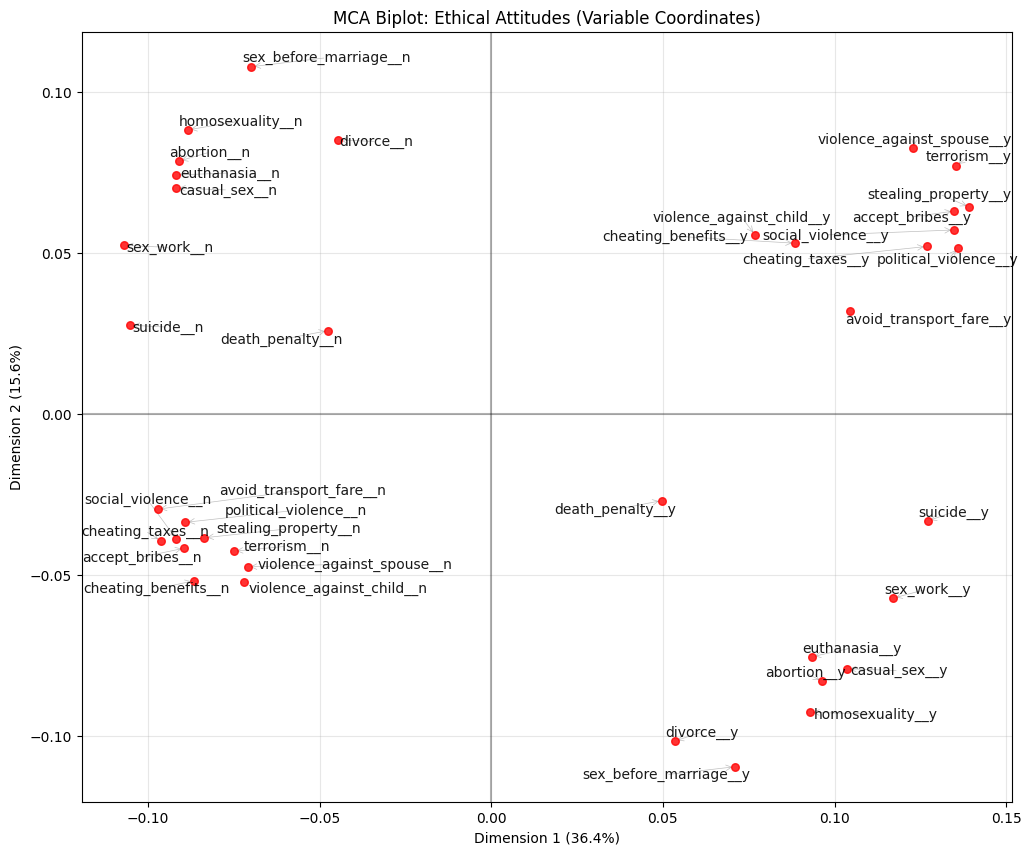

In [ ]:
# Get the actual variable coordinates for MCA biplot
eigenvals = mca.eigenvalues_[:2]  # Remove .values since it's already a numpy array
print("Eigenvalues for first 2 dims:", eigenvals)

# Get the V matrix (right singular vectors) from SVD
V = mca.svd_.V[:2].T  # Take first 2 components and transpose
print("V matrix shape:", V.shape)

# Calculate variable coordinates: V * sqrt(eigenvalues)
coords = V * np.sqrt(eigenvals)
print("Coordinates shape:", coords.shape)

# Create the proper biplot DataFrame with actual coordinates
df_biplot = pd.DataFrame(
    {"labels": mca.one_hot_columns_, "dim1": coords[:, 0], "dim2": coords[:, 1]}
)

print("First few rows of biplot data:")
print(df_biplot.head())

# Plot with repelling text and no backgrounds
plt.figure(figsize=(12, 10))

texts = []
for i, row in df_biplot.iterrows():
    # Add scatter points
    plt.scatter(row["dim1"], row["dim2"], color="red", s=30, alpha=0.8, zorder=5)

    # Create text objects for repelling
    text = plt.text(
        row["dim1"],
        row["dim2"],
        row["labels"],
        fontsize=10,
        ha="center",
        va="center",
        alpha=0.9,
        zorder=10,
    )  # No bbox background
    texts.append(text)

# Adjust text positions to avoid overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color="gray", alpha=0.5, lw=0.5),
    expand_points=(1.2, 1.2),
    expand_text=(1.1, 1.1),
)

plt.xlabel(f"Dimension 1 ({mca.percentage_of_variance_[0]:.1f}%)")
plt.ylabel(f"Dimension 2 ({mca.percentage_of_variance_[1]:.1f}%)")
plt.title("MCA Biplot: Ethical Attitudes (Variable Coordinates)")
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.axvline(x=0, color="black", linestyle="-", alpha=0.3)
plt.show()

🗣️ **DISCUSSION**: What patterns do you see in the ethical attitudes? Which attitudes cluster together?

---

# Part III: Autoencoders - Non-linear Dimensionality Reduction (25 mins)

Autoencoders use neural networks to learn non-linear compressions of data, potentially capturing more complex patterns than PCA.

## Prepare Data for Autoencoders

In [ ]:
# Clean and normalize IQ data for autoencoder
autoencoder_data = X_train.copy()

# Standardize the data
scaler_ae = StandardScaler()
data_scaled = scaler_ae.fit_transform(autoencoder_data)

print(f"Input dimensions: {data_scaled.shape}")
input_dim = data_scaled.shape[1]
encoding_dim = 6

# Convert to PyTorch tensors
data_tensor = torch.FloatTensor(data_scaled)

Input dimensions: (240, 25)


## Define Autoencoder Architecture

In [ ]:
class IQAutoencoder(nn.Module):
    def __init__(self, input_dim=24, encoding_dim=6):
        super(IQAutoencoder, self).__init__()
        
        # Encoder: compress input_dim -> encoding_dim dimensions
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(12, encoding_dim)
        )
        
        # Decoder: reconstruct encoding_dim -> input_dim dimensions
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 12),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(12, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        return self.encoder(x)

# Initialize the model
model = IQAutoencoder(input_dim=input_dim, encoding_dim=encoding_dim)
print("Autoencoder architecture:")
print(model)

Autoencoder architecture:
IQAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=25, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=12, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=12, out_features=6, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=6, out_features=12, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=12, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=25, bias=True)
  )
)


## Train the Autoencoder

In [ ]:
# Training setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data_tensor = data_tensor.to(device)

# Split data for training and validation
train_size = int(0.8 * len(data_tensor))
val_size = len(data_tensor) - train_size
train_data, val_data = torch.utils.data.random_split(data_tensor, [train_size, val_size])

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Training parameters
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
epochs = 100

# Training loop
train_losses = []
val_losses = []

print("Training autoencoder...")

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            output = model(batch)
            loss = criterion(output, batch)
            val_loss += loss.item()
    
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

print("Training complete!")

Training autoencoder...
Epoch 20, Train Loss: 0.8116, Val Loss: 0.7395
Epoch 40, Train Loss: 0.7725, Val Loss: 0.6933
Epoch 60, Train Loss: 0.7283, Val Loss: 0.6700
Epoch 80, Train Loss: 0.7308, Val Loss: 0.6607
Epoch 100, Train Loss: 0.7160, Val Loss: 0.6433
Training complete!


## Extract and Analyze Encoded Representations

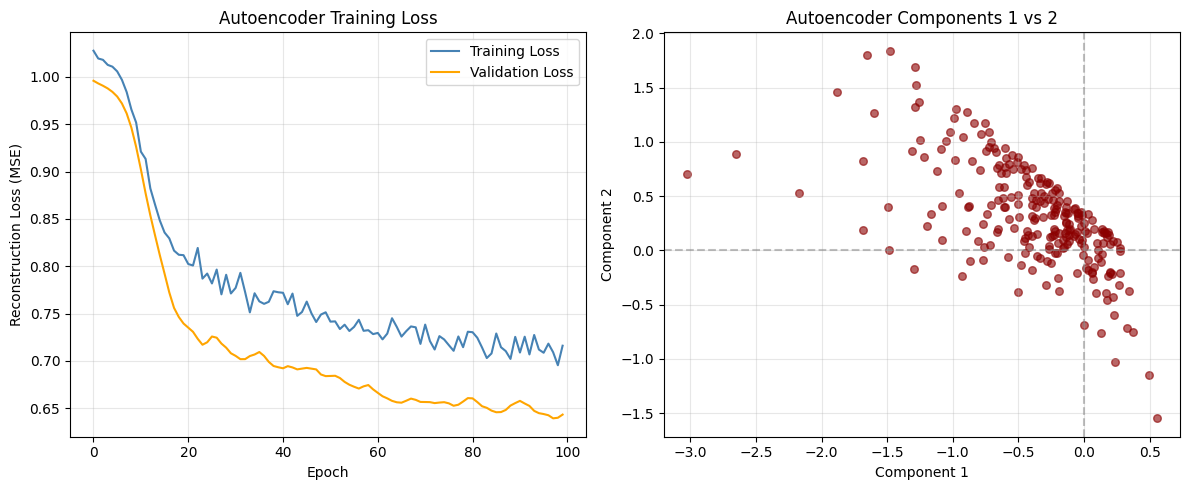

In [ ]:
# Plot training loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='steelblue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (MSE)')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Get encoded representations
model.eval()
with torch.no_grad():
    encoded_data = model.encode(data_tensor).cpu().numpy()

encoded_df = pd.DataFrame(encoded_data, columns=[f'AE_Component_{i+1}' for i in range(encoding_dim)])

# Visualize first two autoencoder components
plt.subplot(1, 2, 2)
plt.scatter(encoded_df['AE_Component_1'], encoded_df['AE_Component_2'], 
           alpha=0.6, color='darkred', s=30)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Autoencoder Components 1 vs 2')
plt.axhline(y=0, linestyle='--', alpha=0.5, color='gray')
plt.axvline(x=0, linestyle='--', alpha=0.5, color='gray')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation with original features

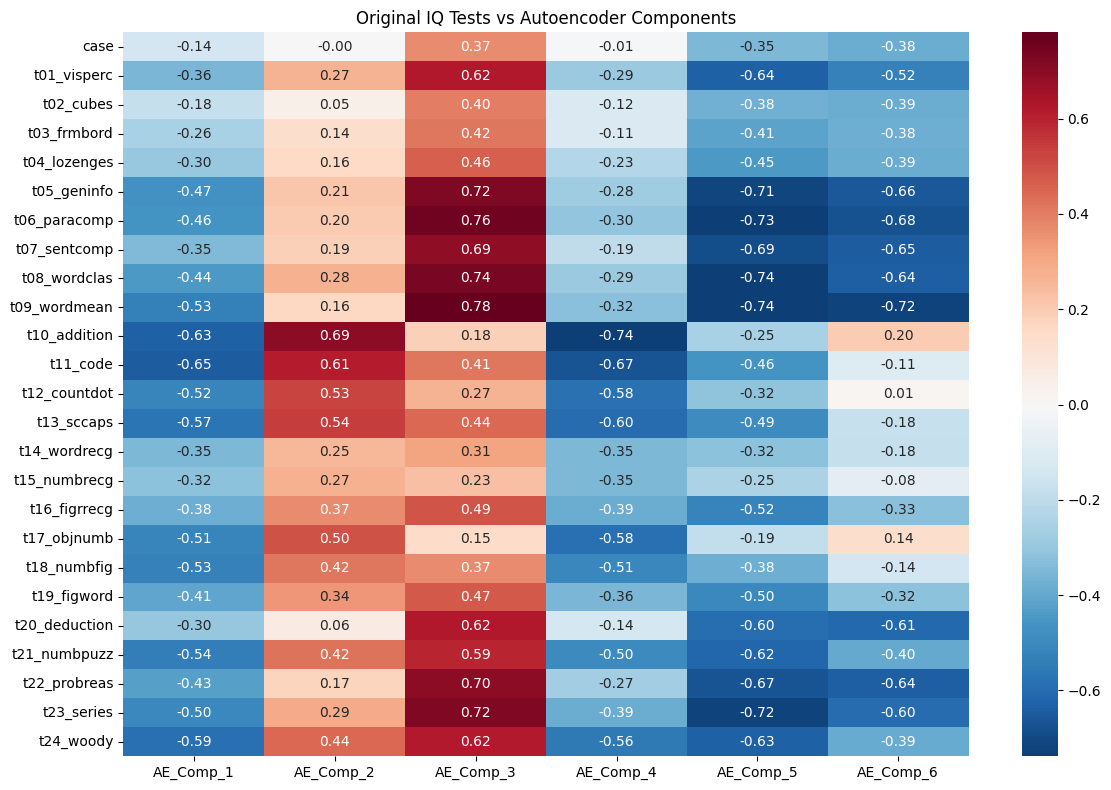

In [ ]:
# Calculate correlations between original variables and encoded components
original_data_df = pd.DataFrame(data_scaled, columns=X_train.columns)
correlations_ae = np.corrcoef(original_data_df.values.T, encoded_df.values.T)

# Extract correlations between original variables and autoencoder components
n_original = len(original_data_df.columns)
correlations_subset = correlations_ae[:n_original, n_original:]

# Create heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(correlations_subset, 
           xticklabels=[f'AE_Comp_{i+1}' for i in range(encoding_dim)],
           yticklabels=original_data_df.columns,
           annot=True, 
           cmap='RdBu_r', 
           center=0,
           fmt='.2f')
plt.title('Original IQ Tests vs Autoencoder Components')
plt.tight_layout()
plt.show()

---

# Part IV: Method Comparison and Discussion (15 mins)

## Side-by-Side Comparison

Let's compare the three methods we've learned:

| Method | Data Type | Assumptions | Interpretability | Complexity |
|--------|-----------|-------------|------------------|------------|
| **PCA** | Continuous | Linear relationships | High | Low |
| **MCA** | Categorical | Chi-square distances | Medium | Low |
| **Autoencoders** | Any | Non-linear relationships | Low | High |

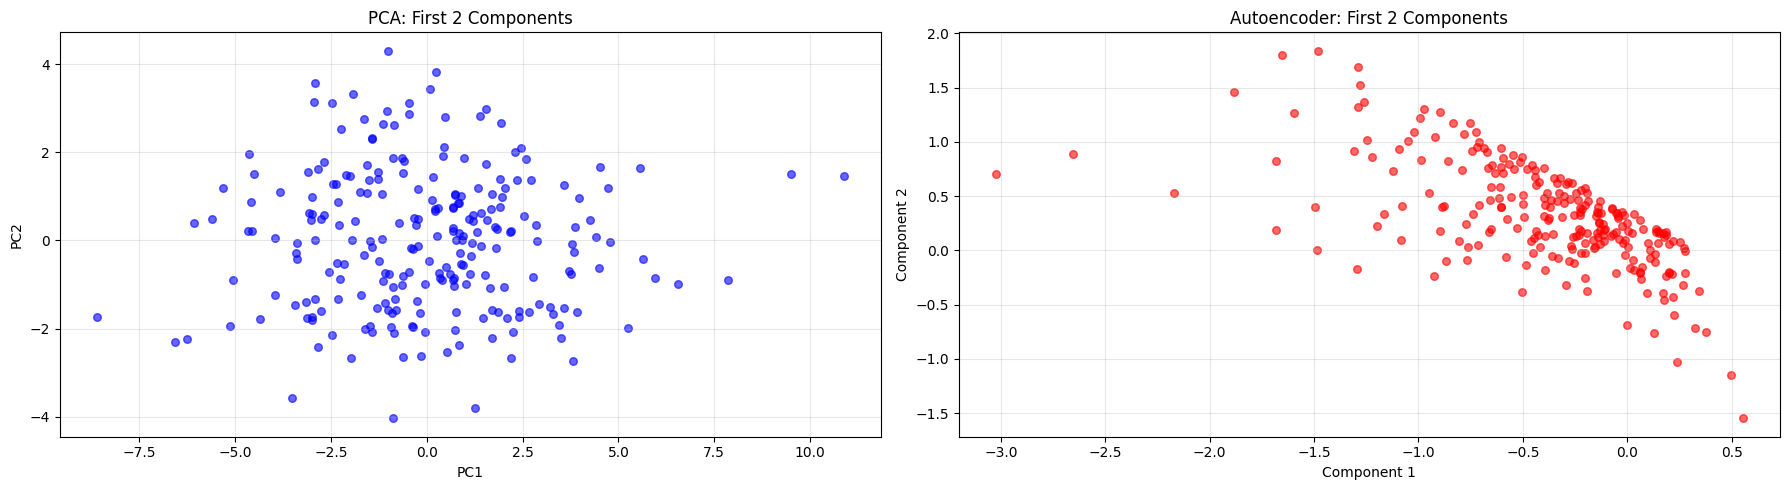

In [ ]:
# Compare first two dimensions from each method
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# PCA plot
axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], alpha=0.6, color="blue", s=30)
axes[0].set_title("PCA: First 2 Components")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, alpha=0.3)

# Autoencoder plot
axes[1].scatter(
    encoded_df["AE_Component_1"],
    encoded_df["AE_Component_2"],
    alpha=0.6,
    color="red",
    s=30,
)
axes[1].set_title("Autoencoder: First 2 Components")
axes[1].set_xlabel("Component 1")
axes[1].set_ylabel("Component 2")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Takeaways

🔑 **When to use each method:**

- **PCA**: When you have continuous data and want interpretable linear combinations
- **MCA**: When working with categorical data or contingency tables  
- **Autoencoders**: When you suspect non-linear relationships or need flexible architectures

## Discussion Questions

🗣️ **Think about these questions:**

1. Which method captured the most variance with fewer components?
2. How do the visualizations differ between methods?
3. When might you choose a more complex method like autoencoders over PCA?
4. What are the trade-offs between interpretability and flexibility?

## Extension Activities

🚀 **Try these on your own:**

1. Experiment with different numbers of components/dimensions
2. Apply these methods to your own datasets
3. Combine dimensionality reduction with clustering or classification
4. Explore other variants like kernel PCA or variational autoencoders

---

**Congratulations!** You've now experienced three fundamental approaches to dimensionality reduction using Python. Each has its strengths and appropriate use cases in the data scientist's toolkit.